# Monte Carlo Simulation

Today we use **Monte Carlo** to price a **European call**: simulate many risk-neutral paths to maturity, take the average discounted payoff.

**Call value (discounted risk-neutral expectation)**

$$
C_0 \approx e^{-rT} \cdot \frac{1}{N} \sum_{i=1}^{N} \max\bigl(S_T^{(i)} - K,\, 0\bigr)
$$

**Terminal price** under geometric Brownian motion (GBM), with $Z_i \sim \mathcal{N}(0,1)$ i.i.d.:

$$
S_T^{(i)} = S_0 \exp\left(\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T}\, Z_i\right)
$$

**Notation**

- $S_0$ — current stock price  
- $K$ — strike price  
- $r$ — risk-free rate (continuously compounded)  
- $\sigma$ — volatility  
- $T$ — time to maturity  
- $N$ — number of simulated paths

In [4]:
import numpy as np
import matplotlib.pyplot as plt

S0 = 100      # current stock price
K = 110       # strike price
r = 0.05      # risk-free rate
sigma = 0.20  # volatility
T = 1.0       # time to maturity in years
N = 10000     # number of simulations

np.random.seed(42)

Z = np.random.randn(N)
Z[:10]

array([ 0.49671415, -0.1382643 ,  0.64768854,  1.52302986, -0.23415337,
       -0.23413696,  1.57921282,  0.76743473, -0.46947439,  0.54256004])

In [7]:
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

print("First 10 simulated stock prices at maturity:")
print(ST[:10])

print("Average simulated stock price:", np.mean(ST))

First 10 simulated stock prices at maturity:
[113.8080226  100.23498965 117.29684912 139.73896651  98.33101696
  98.33133983 141.31801116 120.1399282   93.81036104 114.85634743]
Average simulated stock price: 105.09703823314912


In [8]:
payoff = np.maximum(ST - K, 0)
payoff[:10]

array([ 3.8080226 ,  0.        ,  7.29684912, 29.73896651,  0.        ,
        0.        , 31.31801116, 10.1399282 ,  0.        ,  4.85634743])

In [9]:
call_price = np.exp(-r * T) * np.mean(payoff)
print("Estimated European call option price:", call_price)

Estimated European call option price: 6.044724284446301


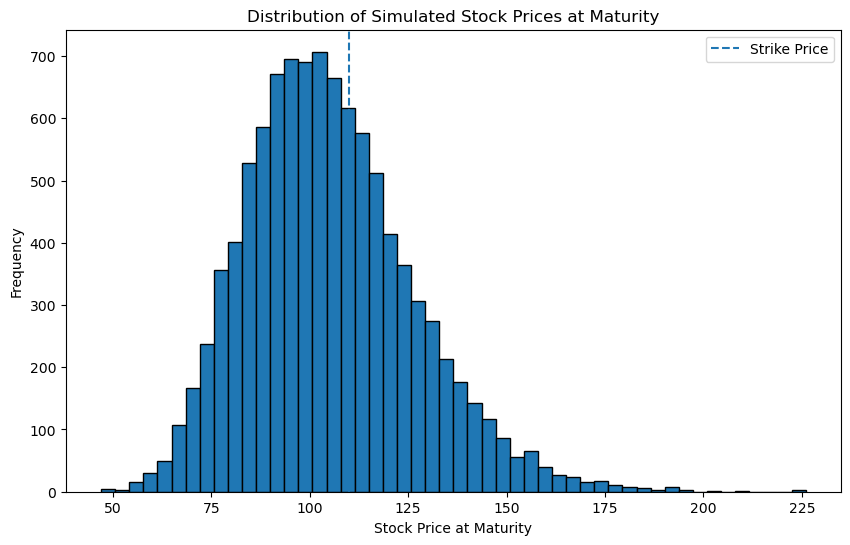

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(ST, bins=50, edgecolor='black')
plt.axvline(K, linestyle='--', label='Strike Price')
plt.title('Distribution of Simulated Stock Prices at Maturity')
plt.xlabel('Stock Price at Maturity')
plt.ylabel('Frequency')
plt.legend()
plt.show()